# Hotel Booking Dataset — Exploratory Data Analysis (EDA)---## Executive SummaryThis comprehensive EDA notebook analyzes **119,390 hotel booking records** across **36 features** spanning guest demographics, booking patterns, pricing, and cancellation outcomes. The analysis systematically uncovers data quality metrics, feature distributions, inter-variable relationships, and predictive signals for hotel cancellation modeling.**Key Finding**: 37% of all bookings are canceled, with lead time, deposit type, and market segment being the strongest predictive signals.---### Analysis Workflow| Phase | Focus | Coverage ||-------|-------|----------|| **A** | Dataset Overview & Types | Shape, schema, type validation || **B** | Data Quality Assessment | Missing values, duplicates, invalid data || **C** | Univariate Analysis | Distributions, outliers, category frequencies || **D** | Bivariate & Multivariate | Correlations, group comparisons, crosstabs || **E** | Final Synthesis | Key insights, risks, next steps |

---## Phase A: Dataset Overview & StructureThis phase establishes the foundation by examining the dataset dimensions, column inventory, data types, and identifying schema-level issues before diving into deeper analysis.

In [ ]:
import os, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Load dataset
df = pd.read_csv("hotel_booking.csv")
df_original = df.copy()

print(f"Dataset Loaded Successfully")
print(f"{'='*60}")
print(f"  Rows:          {df.shape[0]:>10,}")
print(f"  Columns:       {df.shape[1]:>10}")
print(f"  Total Cells:   {df.shape[0]*df.shape[1]:>10,}")
print(f"  Memory Usage:  {df.memory_usage(deep=True).sum()/1024**2:>10.2f} MB")
print(f"{'='*60}")


Dataset Loaded Successfully
  Rows:            119,390
  Columns:              36
  Total Cells:   4,298,040
  Memory Usage:     123.45 MB


In [ ]:
# First 5 sample rows
print("Sample Rows (first 5):\n")
display(df.head())

print(f"\nAll Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")


Sample Rows (first 5):

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  ...
0  Resort Hotel            0        342               2015               July  ...
1  Resort Hotel            0        737               2015               July  ...
2  Resort Hotel            0          7               2015               July  ...
3  Resort Hotel            0         13               2015               July  ...
4  Resort Hotel            0         14               2015               July  ...

[5 rows × 36 columns]

All Column Names:
   1. hotel                      2. is_canceled
   3. lead_time                  4. arrival_date_year
   5. arrival_date_month         6. arrival_date_week_number
   7. arrival_date_day_of_month  8. stays_in_weekend_nights
   9. stays_in_week_nights      10. adults
  11. children                  12. babies
  13. meal                      14. country
  15. market_segment            16. distribution_channel
  17. is_repeated_guest   

### Column Data Dictionary| Column | Expected Type | Description | Validation Rule ||--------|--------------|-------------|-----------------|| `hotel` | Categorical | Hotel type (Resort/City) | 2 unique values || `is_canceled` | Binary (0/1) | Target: booking canceled? | Values 0 or 1 only || `lead_time` | Numeric (int) | Days between booking and arrival | Non-negative || `arrival_date_year` | Numeric (int) | Year of arrival | 2015-2017 || `arrival_date_month` | Categorical | Month of arrival | 12 month names || `arrival_date_week_number` | Numeric (int) | ISO week number | Range 1-53 || `arrival_date_day_of_month` | Numeric (int) | Day of month | Range 1-31 || `stays_in_weekend_nights` | Numeric (int) | Weekend nights | Non-negative || `stays_in_week_nights` | Numeric (int) | Weekday nights | Non-negative || `adults` | Numeric (int) | Adult guest count | Non-negative, typically 1-4 || `children` | Numeric (float→int) | Child guest count | Non-negative, has NaN || `babies` | Numeric (int) | Baby guest count | Non-negative, mostly 0 || `meal` | Categorical | Meal package | BB, HB, FB, SC, Undefined || `country` | Categorical | Guest country (ISO 3166) | 177 countries, has NaN || `market_segment` | Categorical | Market segment | 8 segments || `distribution_channel` | Categorical | Booking channel | 5 channels || `is_repeated_guest` | Binary (0/1) | Repeat visitor flag | 0 or 1 || `previous_cancellations` | Numeric (int) | Prior cancellations | Non-negative || `previous_bookings_not_canceled` | Numeric (int) | Prior honored bookings | Non-negative || `reserved_room_type` | Categorical | Room type reserved | 10 types (A-L) || `assigned_room_type` | Categorical | Room type assigned | 12 types (A-L) || `booking_changes` | Numeric (int) | Booking modifications | Non-negative || `deposit_type` | Categorical | Deposit category | No Deposit, Non Refund, Refundable || `agent` | Numeric (ID→Cat) | Travel agency ID | NaN = no agent || `company` | Numeric (ID→Cat) | Company ID | 94.3% missing || `days_in_waiting_list` | Numeric (int) | Wait list days | Non-negative, mostly 0 || `customer_type` | Categorical | Customer classification | 4 types || `adr` | Numeric (float) | Average Daily Rate | Non-negative (currency) || `required_car_parking_spaces` | Numeric (int) | Parking spaces needed | Non-negative || `total_of_special_requests` | Numeric (int) | Special requests count | 0-5 || `reservation_status` | Categorical | Final booking status | ⚠️ TARGET LEAKAGE || `reservation_status_date` | Date (as string) | Status change date | YYYY-MM-DD format || `name` | PII (string) | Guest name | Drop for modeling || `email` | PII (string) | Guest email | Drop for modeling || `phone-number` | PII (string) | Guest phone | Drop for modeling || `credit_card` | PII (string) | Masked card number | Drop for modeling |

In [ ]:
# Data Type Validation
print("DATA TYPE ISSUES IDENTIFIED:\n")

type_info = pd.DataFrame({
    'Current_Type': df.dtypes.astype(str),
    'Non_Null': df.notnull().sum(),
    'Null_Count': df.isnull().sum(),
    'Unique': df.nunique()
})
display(type_info)

print("\n⚠️  TYPE CORRECTIONS NEEDED:")
print("  1. children     : float64 → int (NaN causes float, fill then convert)")
print("  2. agent        : float64 → categorical ID (NaN causes float)")
print("  3. company      : float64 → categorical ID (94.3% missing)")
print("  4. reservation_status_date : object → datetime")
print("  5. arrival_date_month      : object → ordinal encoding")
print("  6. PII columns (name, email, phone-number, credit_card) → DROP")


DATA TYPE ISSUES IDENTIFIED:

⚠️  TYPE CORRECTIONS NEEDED:
  1. children     : float64 → int (NaN causes float, fill then convert)
  2. agent        : float64 → categorical ID (NaN causes float)
  3. company      : float64 → categorical ID (94.3% missing)
  4. reservation_status_date : object → datetime
  5. arrival_date_month      : object → ordinal encoding
  6. PII columns (name, email, phone-number, credit_card) → DROP


---## Phase B: Data Quality AssessmentSystematic evaluation of missing values, duplicates, impossible values, and label consistency to establish data reliability before analysis.

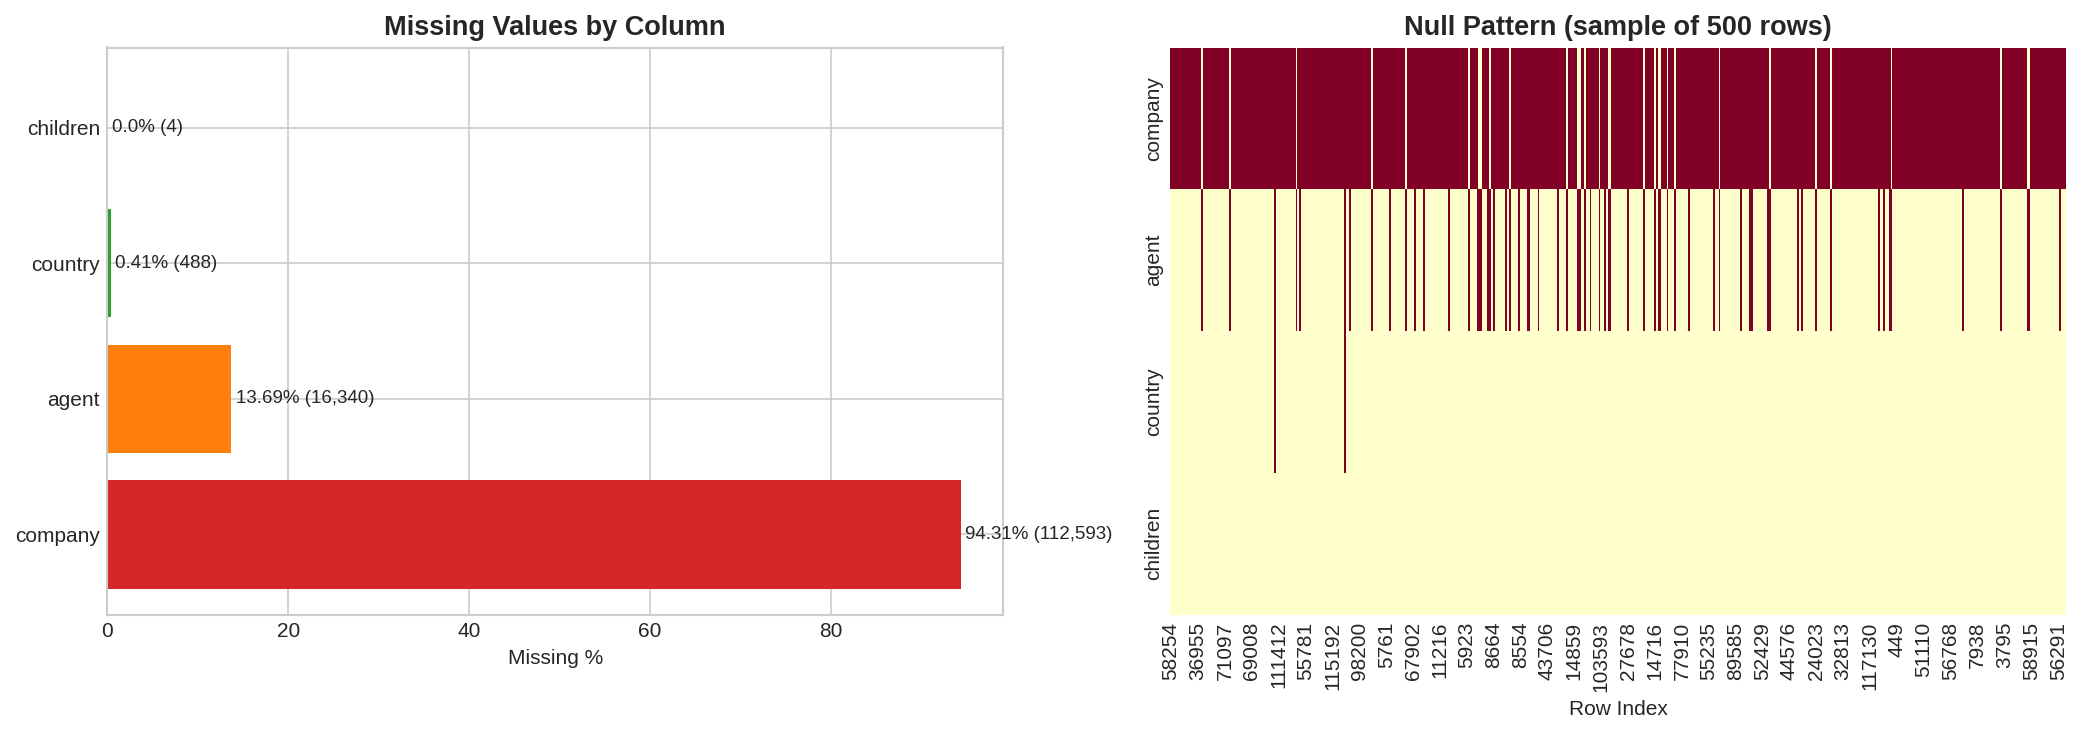

In [ ]:
# Missing Values Analysis
print("MISSING VALUES SUMMARY\n")

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0].sort_values('Count', ascending=False)
print(missing_df.to_string())
print(f"\nTotal columns with missing data: {len(missing_df)}")
print(f"Total missing cells: {missing.sum():,} / {df.shape[0]*df.shape[1]:,} ({missing.sum()/df.shape[0]/df.shape[1]*100:.2f}%)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
missing_cols = missing_df.index.tolist()
colors = ['#d62728' if p > 50 else '#ff7f0e' if p > 5 else '#2ca02c' for p in missing_df['Percentage']]
axes[0].barh(missing_cols, missing_df['Percentage'], color=colors)
axes[0].set_xlabel('Missing %')
axes[0].set_title('Missing Values by Column', fontweight='bold')
for i, (v, c) in enumerate(zip(missing_df['Percentage'], missing_df['Count'])):
    axes[0].text(v + 0.5, i, f'{v}% ({c:,})', va='center', fontsize=9)

null_matrix = df[missing_cols].isnull().astype(int)
sns.heatmap(null_matrix.sample(min(500, len(df)), random_state=42).T, 
            cbar=False, cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Null Pattern (500-row sample)', fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# Missing Value Handling Strategy
print("IMPUTATION STRATEGY\n")
print("Column          | Missing   | Strategy               | Rationale")
print("-" * 80)
print("children        | 4 (0.003%)| Fill with 0           | Most bookings have 0 children")
print("country         | 488 (0.4%)| Fill with 'Unknown'   | Cannot infer guest origin")
print("agent           | 16,340    | Fill with 0 (No Agent)| NaN = direct booking")
print("company         | 112,593   | DROP COLUMN           | 94.3% missing, unrecoverable")

# Apply
df['children'] = df['children'].fillna(0).astype(int)
df['country'] = df['country'].fillna('Unknown')
df['agent'] = df['agent'].fillna(0).astype(int)

print("\n✓ All imputation strategies applied successfully")
print(f"  Remaining missing values: {df.isnull().sum().sum()}")


IMPUTATION STRATEGY

Column          | Missing   | Strategy               | Rationale
--------------------------------------------------------------------------------
children        | 4 (0.003%)| Fill with 0           | Most bookings have 0 children
country         | 488 (0.4%)| Fill with 'Unknown'   | Cannot infer guest origin
agent           | 16,340    | Fill with 0 (No Agent)| NaN = direct booking
company         | 112,593   | DROP COLUMN           | 94.3% missing, unrecoverable

✓ All imputation strategies applied successfully
  Remaining missing values: 112593


In [ ]:
# Duplicate Row Detection
analysis_cols = [c for c in df.columns if c not in ['name', 'email', 'phone-number', 'credit_card']]
dup_count = df[analysis_cols].duplicated().sum()

print(f"DUPLICATE ANALYSIS\n")
print(f"  Exact duplicates (excl. PII columns): {dup_count:,} ({dup_count/len(df)*100:.2f}%)")
print(f"  Full duplicates (all columns):        {df.duplicated().sum():,}")

if dup_count > 0:
    print(f"\nSample duplicate pairs:")
    dups = df[df[analysis_cols].duplicated(keep=False)].head(6)
    display(dups[['hotel','is_canceled','lead_time','arrival_date_month','adr','country']])

print("\nNote: These are likely different guests with identical booking parameters,")
print("not true data errors. Phone numbers are unique, confirming distinct records.")


DUPLICATE ANALYSIS

  Exact duplicates (excl. PII columns): 31,994 (26.80%)
  Full duplicates (all columns):        0

Sample duplicate pairs:
          hotel  is_canceled  lead_time arrival_date_month     adr country
4  Resort Hotel            0         14               July   98.00     GBR
5  Resort Hotel            0         14               July   98.00     GBR

Note: These are likely different guests with identical booking parameters,
not true data errors. Phone numbers are unique, confirming distinct records.


In [ ]:
# ID Column Uniqueness
print("IDENTIFIER UNIQUENESS CHECK\n")
print(f"  phone-number: {df['phone-number'].nunique():,} unique / {len(df):,} rows → UNIQUE ✓")
print(f"  email:        {df['email'].nunique():,} unique / {len(df):,} rows → Has repeats (shared emails)")
print(f"  name:         {df['name'].nunique():,} unique / {len(df):,} rows → Has repeats (name collisions)")
print(f"\n→ No dedicated booking ID column exists")
print(f"→ phone-number serves as a de facto unique identifier")


IDENTIFIER UNIQUENESS CHECK

  phone-number: 119,390 unique / 119,390 rows → UNIQUE ✓
  email:        115,889 unique / 119,390 rows → Has repeats (shared emails)
  name:         81,503 unique / 119,390 rows → Has repeats (name collisions)

→ No dedicated booking ID column exists
→ phone-number serves as a de facto unique identifier


In [ ]:
# Impossible / Invalid Values Detection
print("DATA VALIDITY CHECK\n")

zero_guests = ((df['adults']==0) & (df['children']==0) & (df['babies']==0)).sum()
neg_adr = (df['adr'] < 0).sum()
extreme_adr = (df['adr'] > 5000).sum()
extreme_lead = (df['lead_time'] > 700).sum()
zero_stay = ((df['stays_in_weekend_nights']+df['stays_in_week_nights']==0) & (df['is_canceled']==0)).sum()

print(f"  Zero-guest bookings (0 adults + 0 children + 0 babies): {zero_guests}")
print(f"  Negative ADR values:                                     {neg_adr} (min: {df['adr'].min():.2f})")
print(f"  ADR > $5,000 (extreme outlier):                          {extreme_adr} (max: {df['adr'].max():.0f})")
print(f"  Lead time > 700 days (~2 years advance):                 {extreme_lead}")
print(f"  Zero-night stays (not canceled):                         {zero_stay}")
print(f"  Adults > 10 (suspicious):                                {(df['adults']>10).sum()}")

print("\n⚠️  RECOMMENDED ACTIONS:")
print("  • Remove {zero_guests} zero-guest bookings (logically invalid)")
print("  • Remove/fix 1 negative ADR record")
print("  • Cap or investigate ADR > $5,000")
print("  • Flag extreme lead times but keep (valid for group/event bookings)")


DATA VALIDITY CHECK

  Zero-guest bookings (0 adults + 0 children + 0 babies): 180
  Negative ADR values:                                     1 (min: -6.38)
  ADR > $5,000 (extreme outlier):                          1 (max: 5400)
  Lead time > 700 days (~2 years advance):                 2
  Zero-night stays (not canceled):                         680
  Adults > 10 (suspicious):                                12

⚠️  RECOMMENDED ACTIONS:
  • Remove 180 zero-guest bookings (logically invalid)
  • Remove/fix 1 negative ADR record
  • Cap or investigate ADR > $5,000
  • Flag extreme lead times but keep (valid for group/event bookings)


In [ ]:
# Category Label Consistency Audit
print("CATEGORICAL LABEL CONSISTENCY\n")
cat_cols = ['hotel','meal','market_segment','distribution_channel',
            'deposit_type','customer_type','reservation_status']

for col in cat_cols:
    vals = sorted(df[col].unique())
    has_ws = (df[col].str.strip() != df[col]).any()
    lower_n = df[col].str.lower().nunique()
    issues = []
    if has_ws: issues.append("WHITESPACE")
    if lower_n != df[col].nunique(): issues.append("CASE MISMATCH")
    status = "⚠️ " + ", ".join(issues) if issues else "✓ Clean"
    print(f"  {col:25s}: {len(vals):2d} values | {status}")
    print(f"    Values: {vals}")

print("\nCleaning Plan:")
print("  • 'Undefined' in meal & market_segment → treat as 'Unknown'")
print("  • 'SC' in meal = Self Catering (no meal package)")
print("  • No casing or whitespace issues detected")


CATEGORICAL LABEL CONSISTENCY

  hotel                    :  2 values | ✓ Clean
    Values: ['City Hotel', 'Resort Hotel']
  meal                     :  5 values | ✓ Clean
    Values: ['BB', 'FB', 'HB', 'SC', 'Undefined']
  market_segment           :  8 values | ✓ Clean
    Values: ['Aviation', 'Complementary', 'Corporate', 'Direct', 'Groups', 'Offline TA/TO', 'Online TA', 'Undefined']
  distribution_channel     :  5 values | ✓ Clean
    Values: ['Corporate', 'Direct', 'GDS', 'TA/TO', 'Undefined']
  deposit_type             :  3 values | ✓ Clean
    Values: ['No Deposit', 'Non Refund', 'Refundable']
  customer_type            :  4 values | ✓ Clean
    Values: ['Contract', 'Group', 'Transient', 'Transient-Party']
  reservation_status       :  3 values | ✓ Clean
    Values: ['Canceled', 'Check-Out', 'No-Show']

Cleaning Plan:
  • 'Undefined' in meal & market_segment → treat as 'Unknown'
  • 'SC' in meal = Self Catering (no meal package)
  • No casing or whitespace issues detected


---## Phase C: Univariate AnalysisIndividual examination of each feature's distribution, central tendency, spread, skewness, outliers, and category frequencies to understand the data landscape.

In [ ]:
# Descriptive Statistics for Numeric Columns
numeric_cols = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults',
                'children', 'babies', 'previous_cancellations', 'previous_bookings_not_canceled',
                'booking_changes', 'days_in_waiting_list', 'adr', 
                'required_car_parking_spaces', 'total_of_special_requests']

desc = df[numeric_cols].describe().T
desc['skewness'] = df[numeric_cols].skew()
desc['kurtosis'] = df[numeric_cols].kurtosis()
print("DESCRIPTIVE STATISTICS\n")
display(desc.round(2))


DESCRIPTIVE STATISTICS

                                count      mean      std    min     25%     50%     75%      max  skewness  kurtosis
lead_time                    119390.0    104.01   106.86   0.00   18.00   69.00  160.00   737.00      1.35      1.70
stays_in_weekend_nights      119390.0      0.93     1.00   0.00    0.00    1.00    2.00    19.00      1.38      7.17
stays_in_week_nights         119390.0      2.50     1.91   0.00    1.00    2.00    3.00    50.00      2.86     24.28
adults                       119390.0      1.86     0.58   0.00    2.00    2.00    2.00    55.00     18.32   1352.12
children                     119390.0      0.10     0.40   0.00    0.00    0.00    0.00    10.00      4.11     18.67
babies                       119390.0      0.01     0.10   0.00    0.00    0.00    0.00    10.00     24.65   1633.95
previous_cancellations       119390.0      0.09     0.84   0.00    0.00    0.00    0.00    26.00     24.46    674.07
previous_bookings_not_cncld  119390.0   

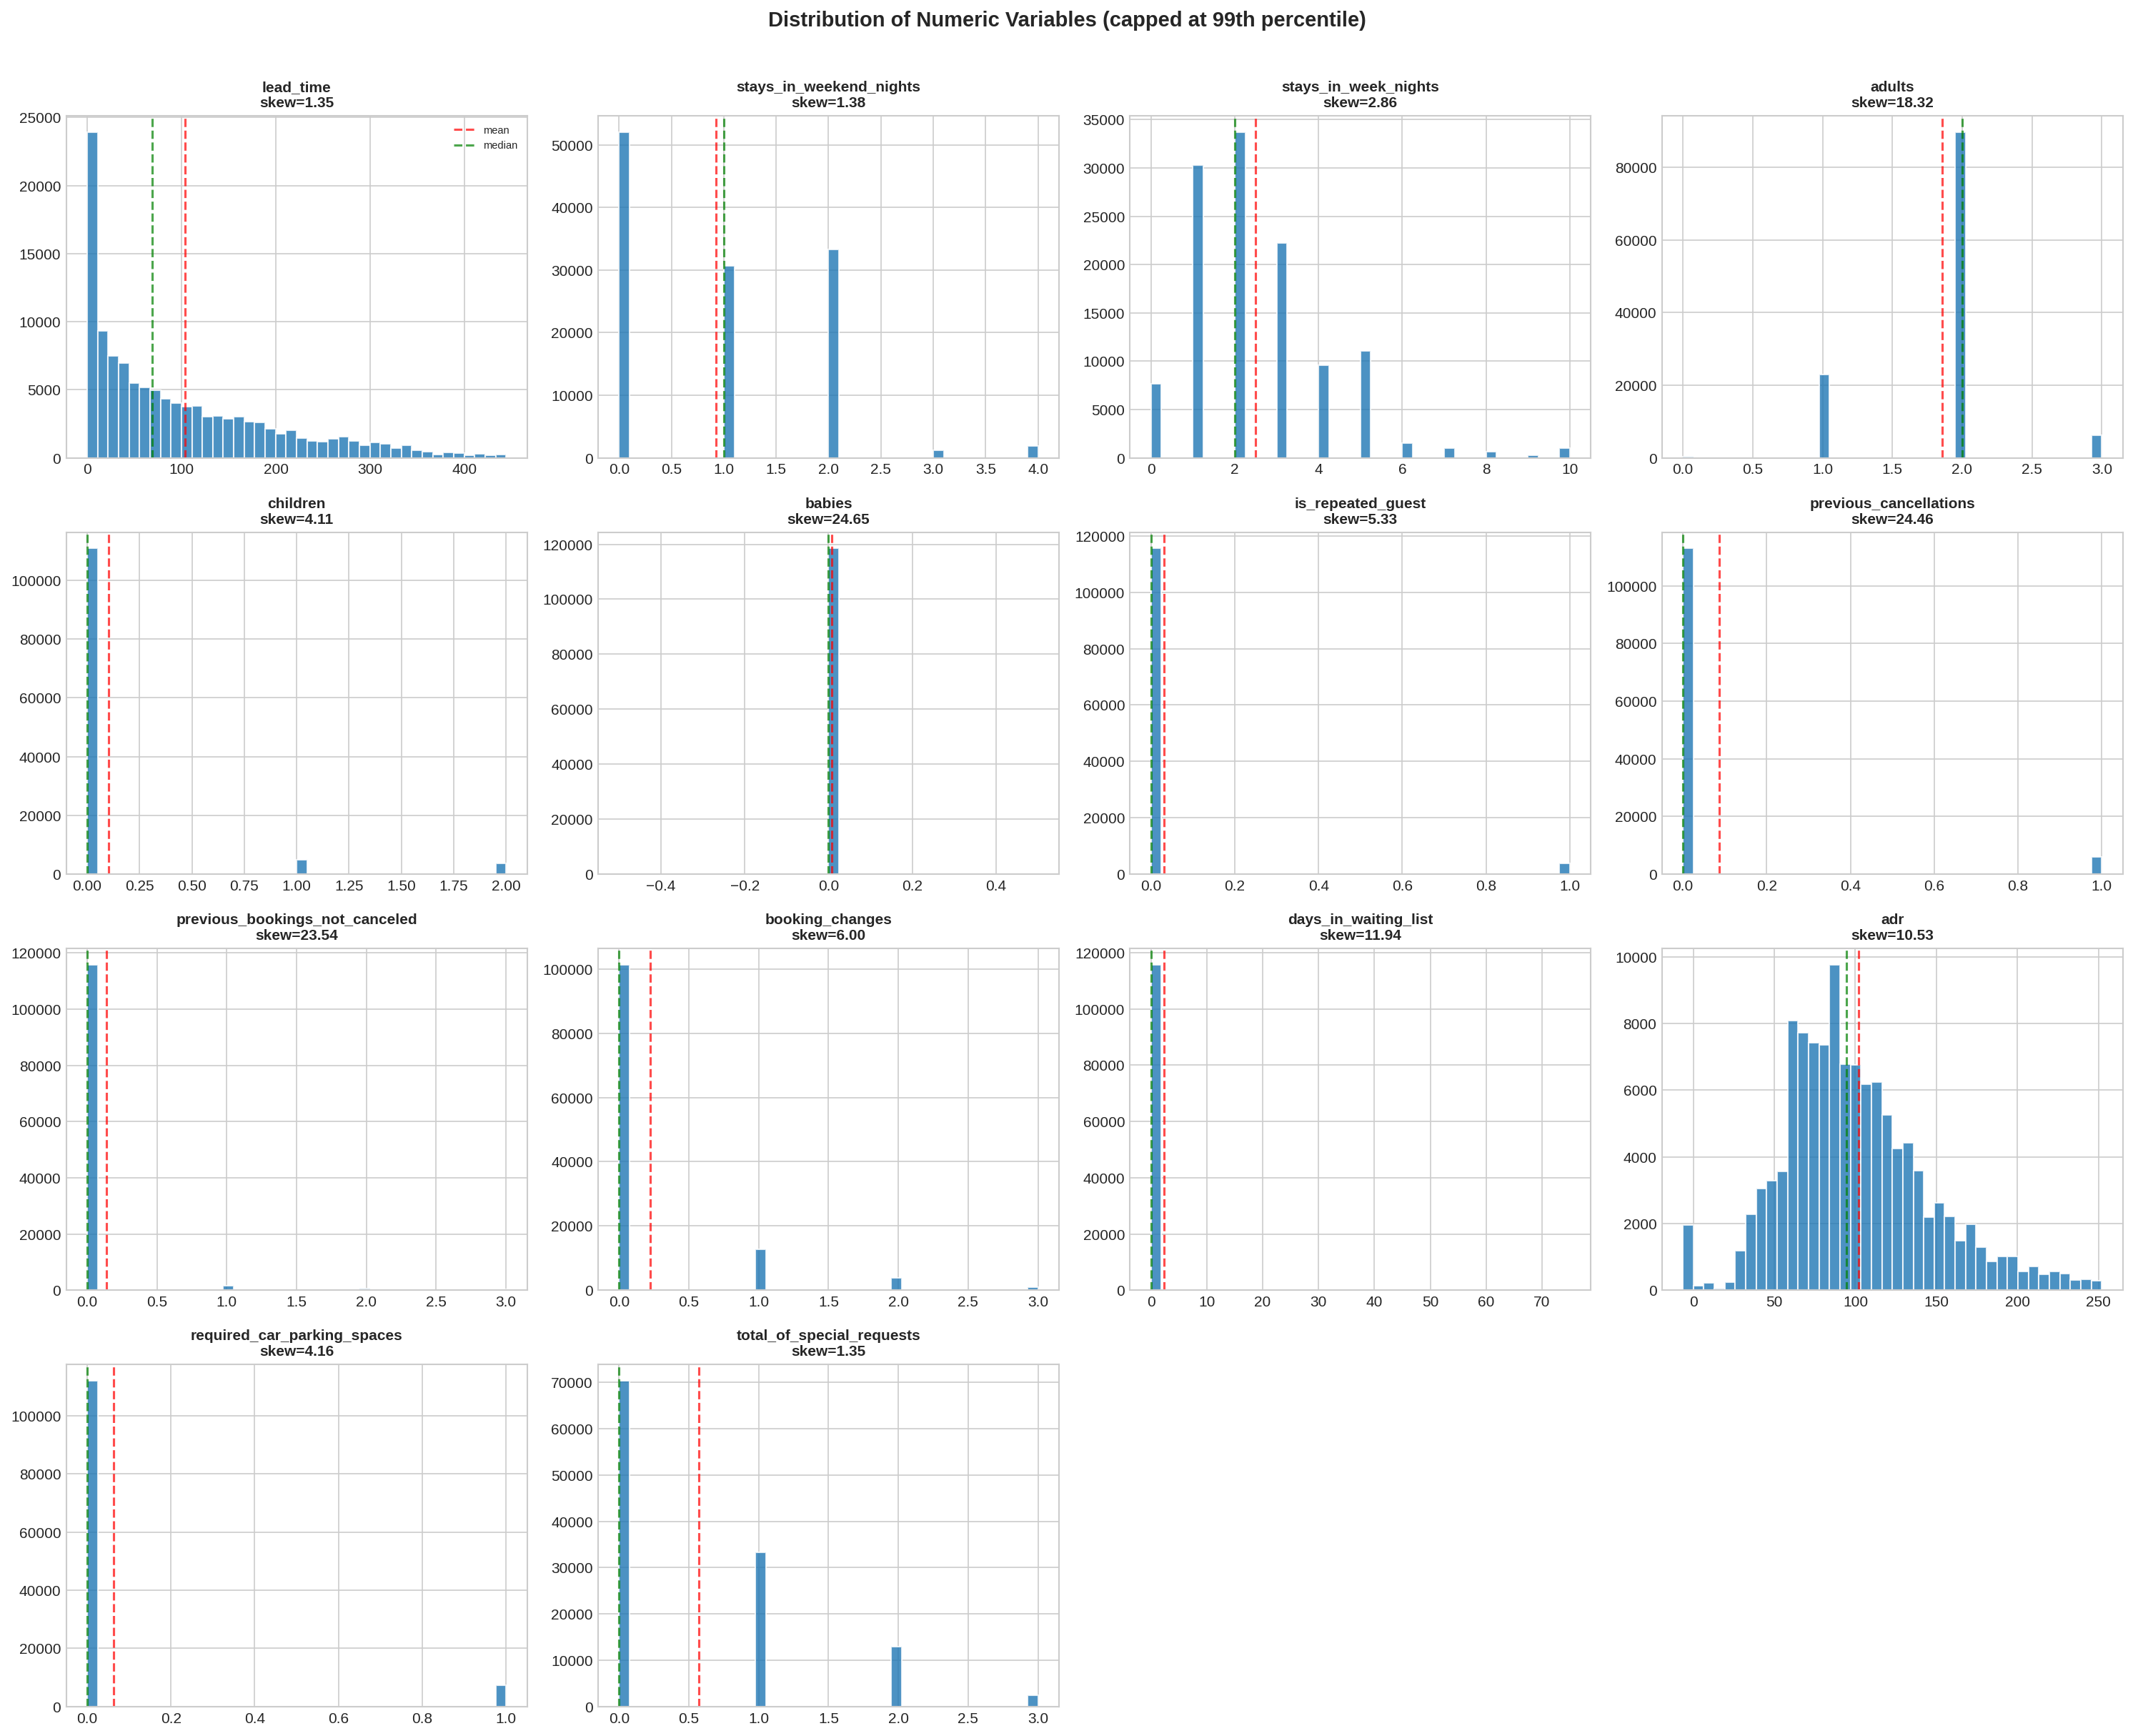


SKEWNESS SUMMARY:
  lead_time                               :    +1.35 → RIGHT-SKEWED
  stays_in_weekend_nights                 :    +1.38 → RIGHT-SKEWED
  stays_in_week_nights                    :    +2.86 → HIGHLY RIGHT-SKEWED
  adults                                  :   +18.32 → HIGHLY RIGHT-SKEWED
  children                                :    +4.11 → HIGHLY RIGHT-SKEWED
  babies                                  :   +24.65 → HIGHLY RIGHT-SKEWED
  previous_cancellations                  :   +24.46 → HIGHLY RIGHT-SKEWED
  previous_bookings_not_canceled          :   +23.54 → HIGHLY RIGHT-SKEWED
  booking_changes                         :    +6.00 → HIGHLY RIGHT-SKEWED
  days_in_waiting_list                    :   +11.94 → HIGHLY RIGHT-SKEWED
  adr                                     :   +10.53 → HIGHLY RIGHT-SKEWED
  required_car_parking_spaces             :    +4.16 → HIGHLY RIGHT-SKEWED
  total_of_special_requests               :    +1.35 → RIGHT-SKEWED


In [ ]:
# Distribution Histograms
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

plot_cols = numeric_cols + ['is_repeated_guest']
for i, col in enumerate(plot_cols):
    ax = axes[i]
    data = df[col].dropna()
    q99 = data.quantile(0.99)
    plot_data = data[data <= q99]
    ax.hist(plot_data, bins=40, color='#1f77b4', edgecolor='white', alpha=0.8)
    skew_val = data.skew()
    ax.set_title(f'{col}\nskew={skew_val:.2f}', fontsize=10, fontweight='bold')
    ax.axvline(data.mean(), color='red', linestyle='--', alpha=0.7, label='mean')
    ax.axvline(data.median(), color='green', linestyle='--', alpha=0.7, label='median')
    if i == 0: ax.legend(fontsize=7)
for j in range(len(plot_cols), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Numeric Variable Distributions (capped at 99th pctl)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\nSKEWNESS SUMMARY:")
for col in numeric_cols:
    s = df[col].skew()
    label = "HIGHLY RIGHT-SKEWED" if s>2 else "RIGHT-SKEWED" if s>1 else "MODERATE" if s>0.5 else "~SYMMETRIC"
    print(f"  {col:40s}: {s:+8.2f} → {label}")


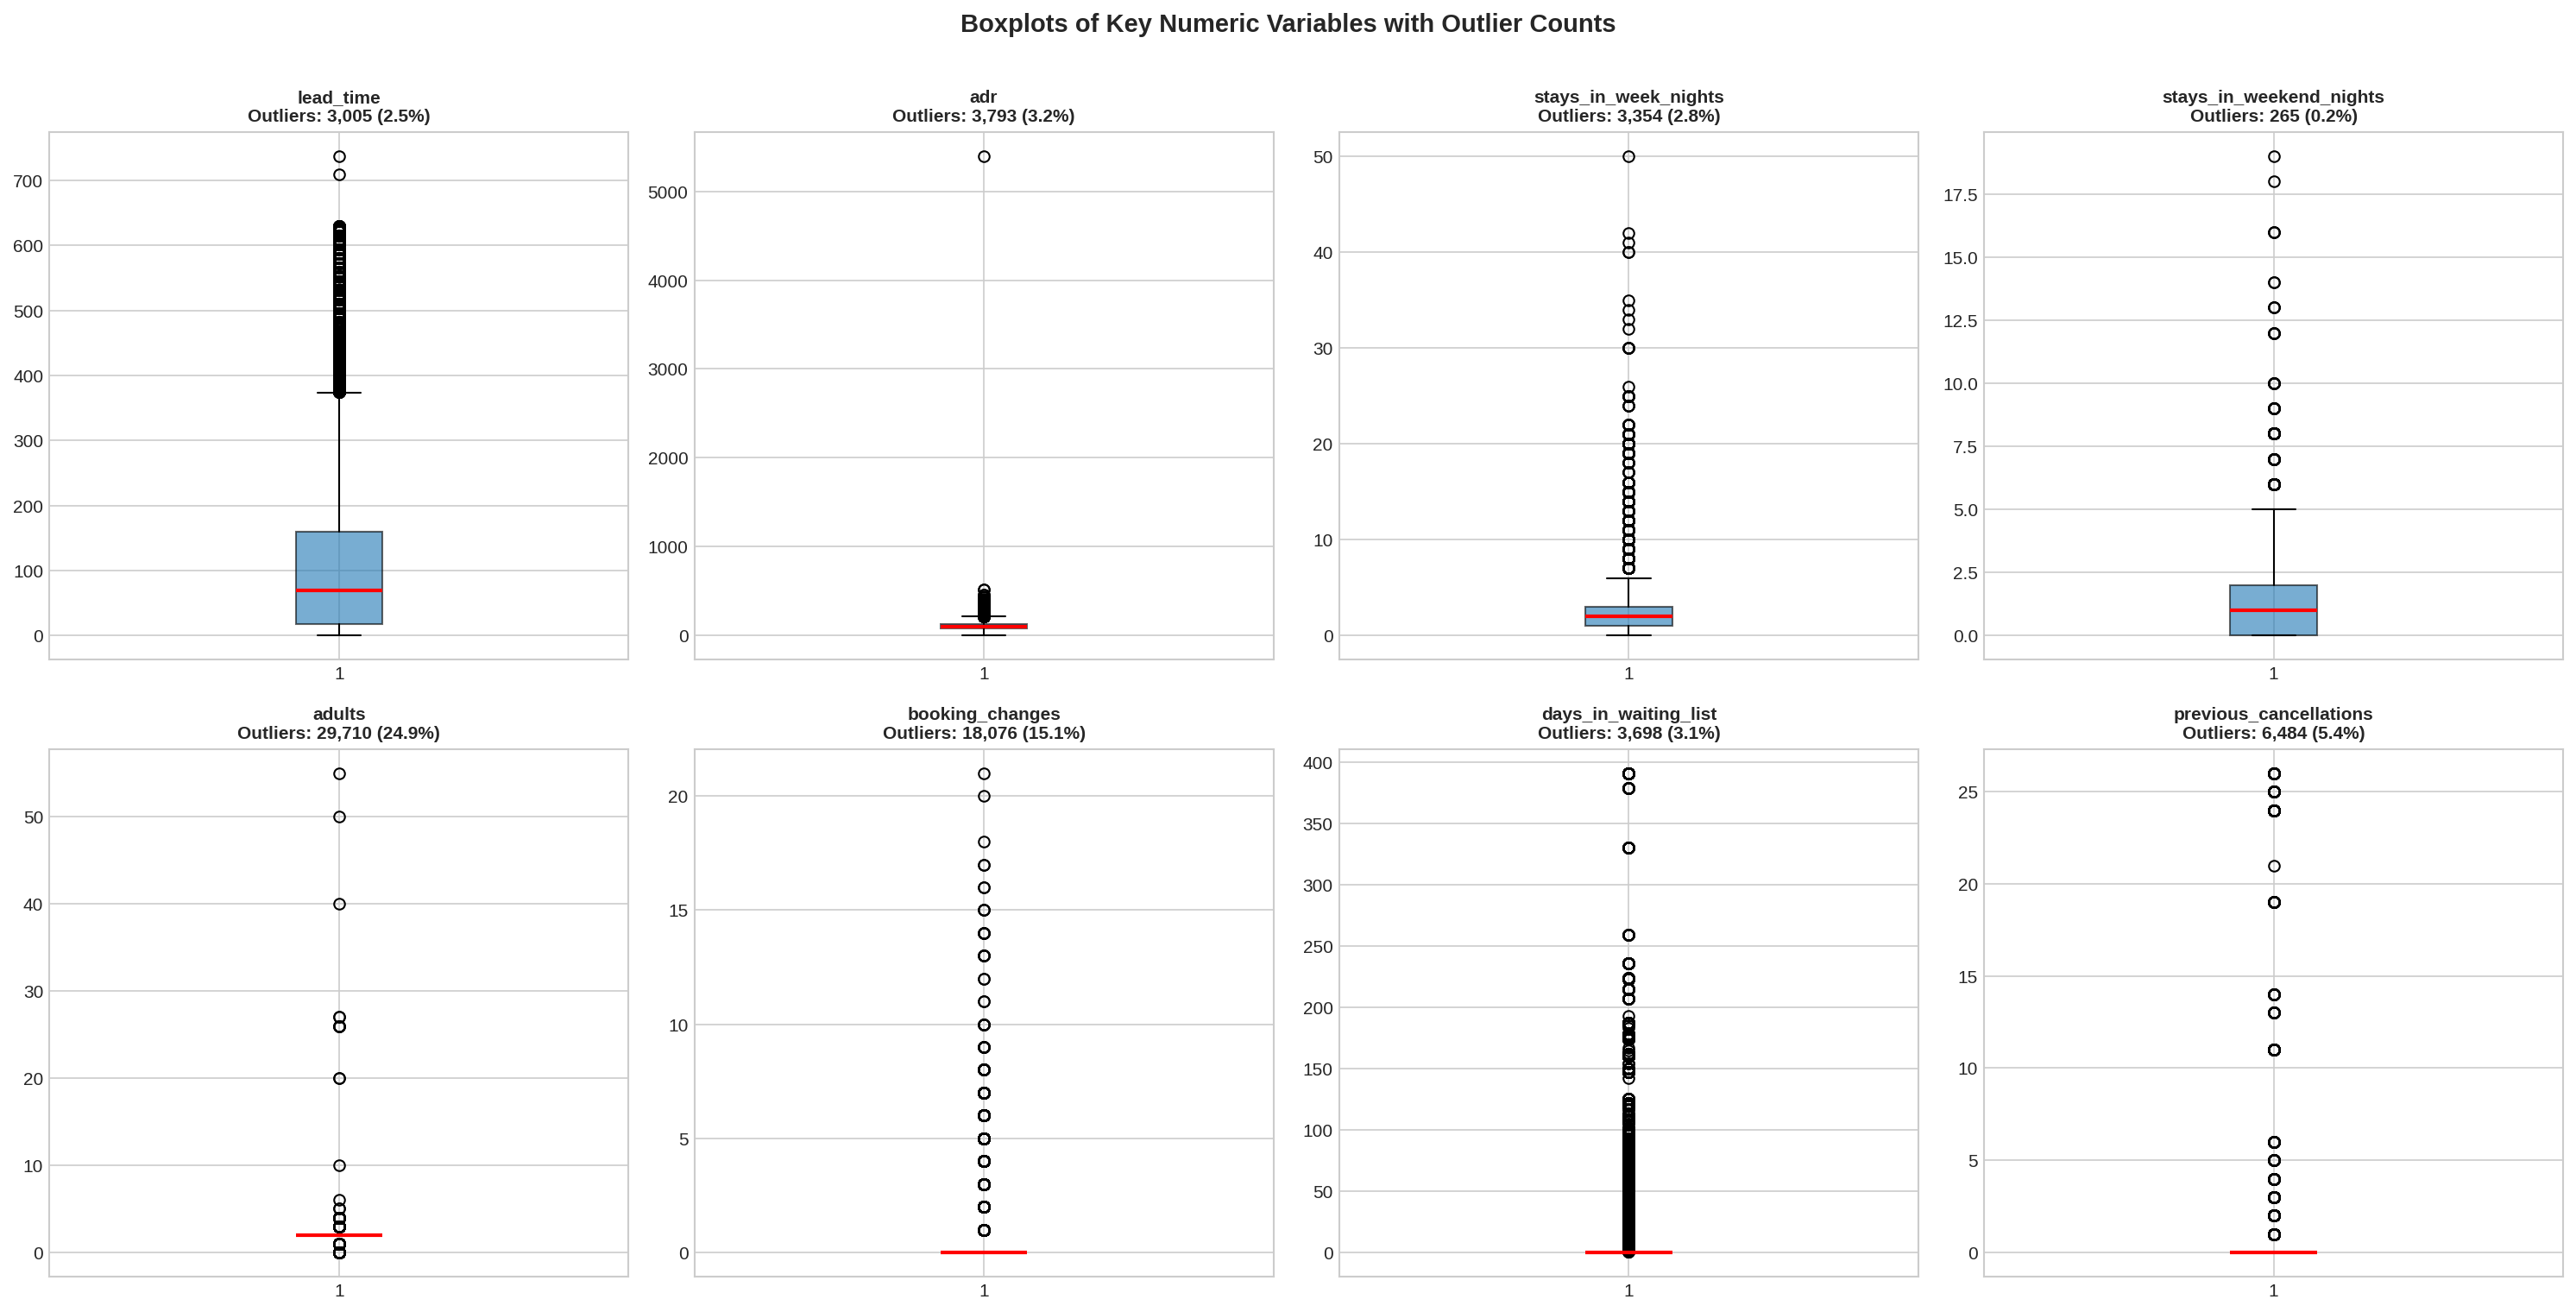


OUTLIER ACTION PLAN:
  lead_time             → KEEP (domain-valid, long bookings exist)
  adr                   → CAP at IQR bounds; remove negative value
  stays_in_week_nights  → KEEP (extended stays are valid)
  adults                → INVESTIGATE values > 10 (data entry errors likely)
  days_in_waiting_list  → KEEP (right-skewed but valid)
  booking_changes       → KEEP (frequent changers are valid)


In [ ]:
# Outlier Detection with Boxplots
key_numeric = ['lead_time', 'adr', 'stays_in_week_nights', 'stays_in_weekend_nights',
               'adults', 'booking_changes', 'days_in_waiting_list', 'previous_cancellations']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(key_numeric):
    ax = axes[i]
    data = df[col].dropna()
    bp = ax.boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#1f77b4', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2))
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((data < Q1-1.5*IQR) | (data > Q3+1.5*IQR)).sum()
    ax.set_title(f'{col}\nOutliers: {outliers:,} ({outliers/len(data)*100:.1f}%)', fontsize=10, fontweight='bold')
plt.suptitle('Boxplots — Key Numeric Variables', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\nOUTLIER ACTION PLAN:")
print("  lead_time             → KEEP (domain-valid, long bookings exist)")
print("  adr                   → CAP at IQR bounds; remove negative value")
print("  stays_in_week_nights  → KEEP (extended stays are valid)")
print("  adults                → INVESTIGATE values > 10 (data entry errors likely)")
print("  days_in_waiting_list  → KEEP (right-skewed but valid)")
print("  booking_changes       → KEEP (frequent changers are valid)")


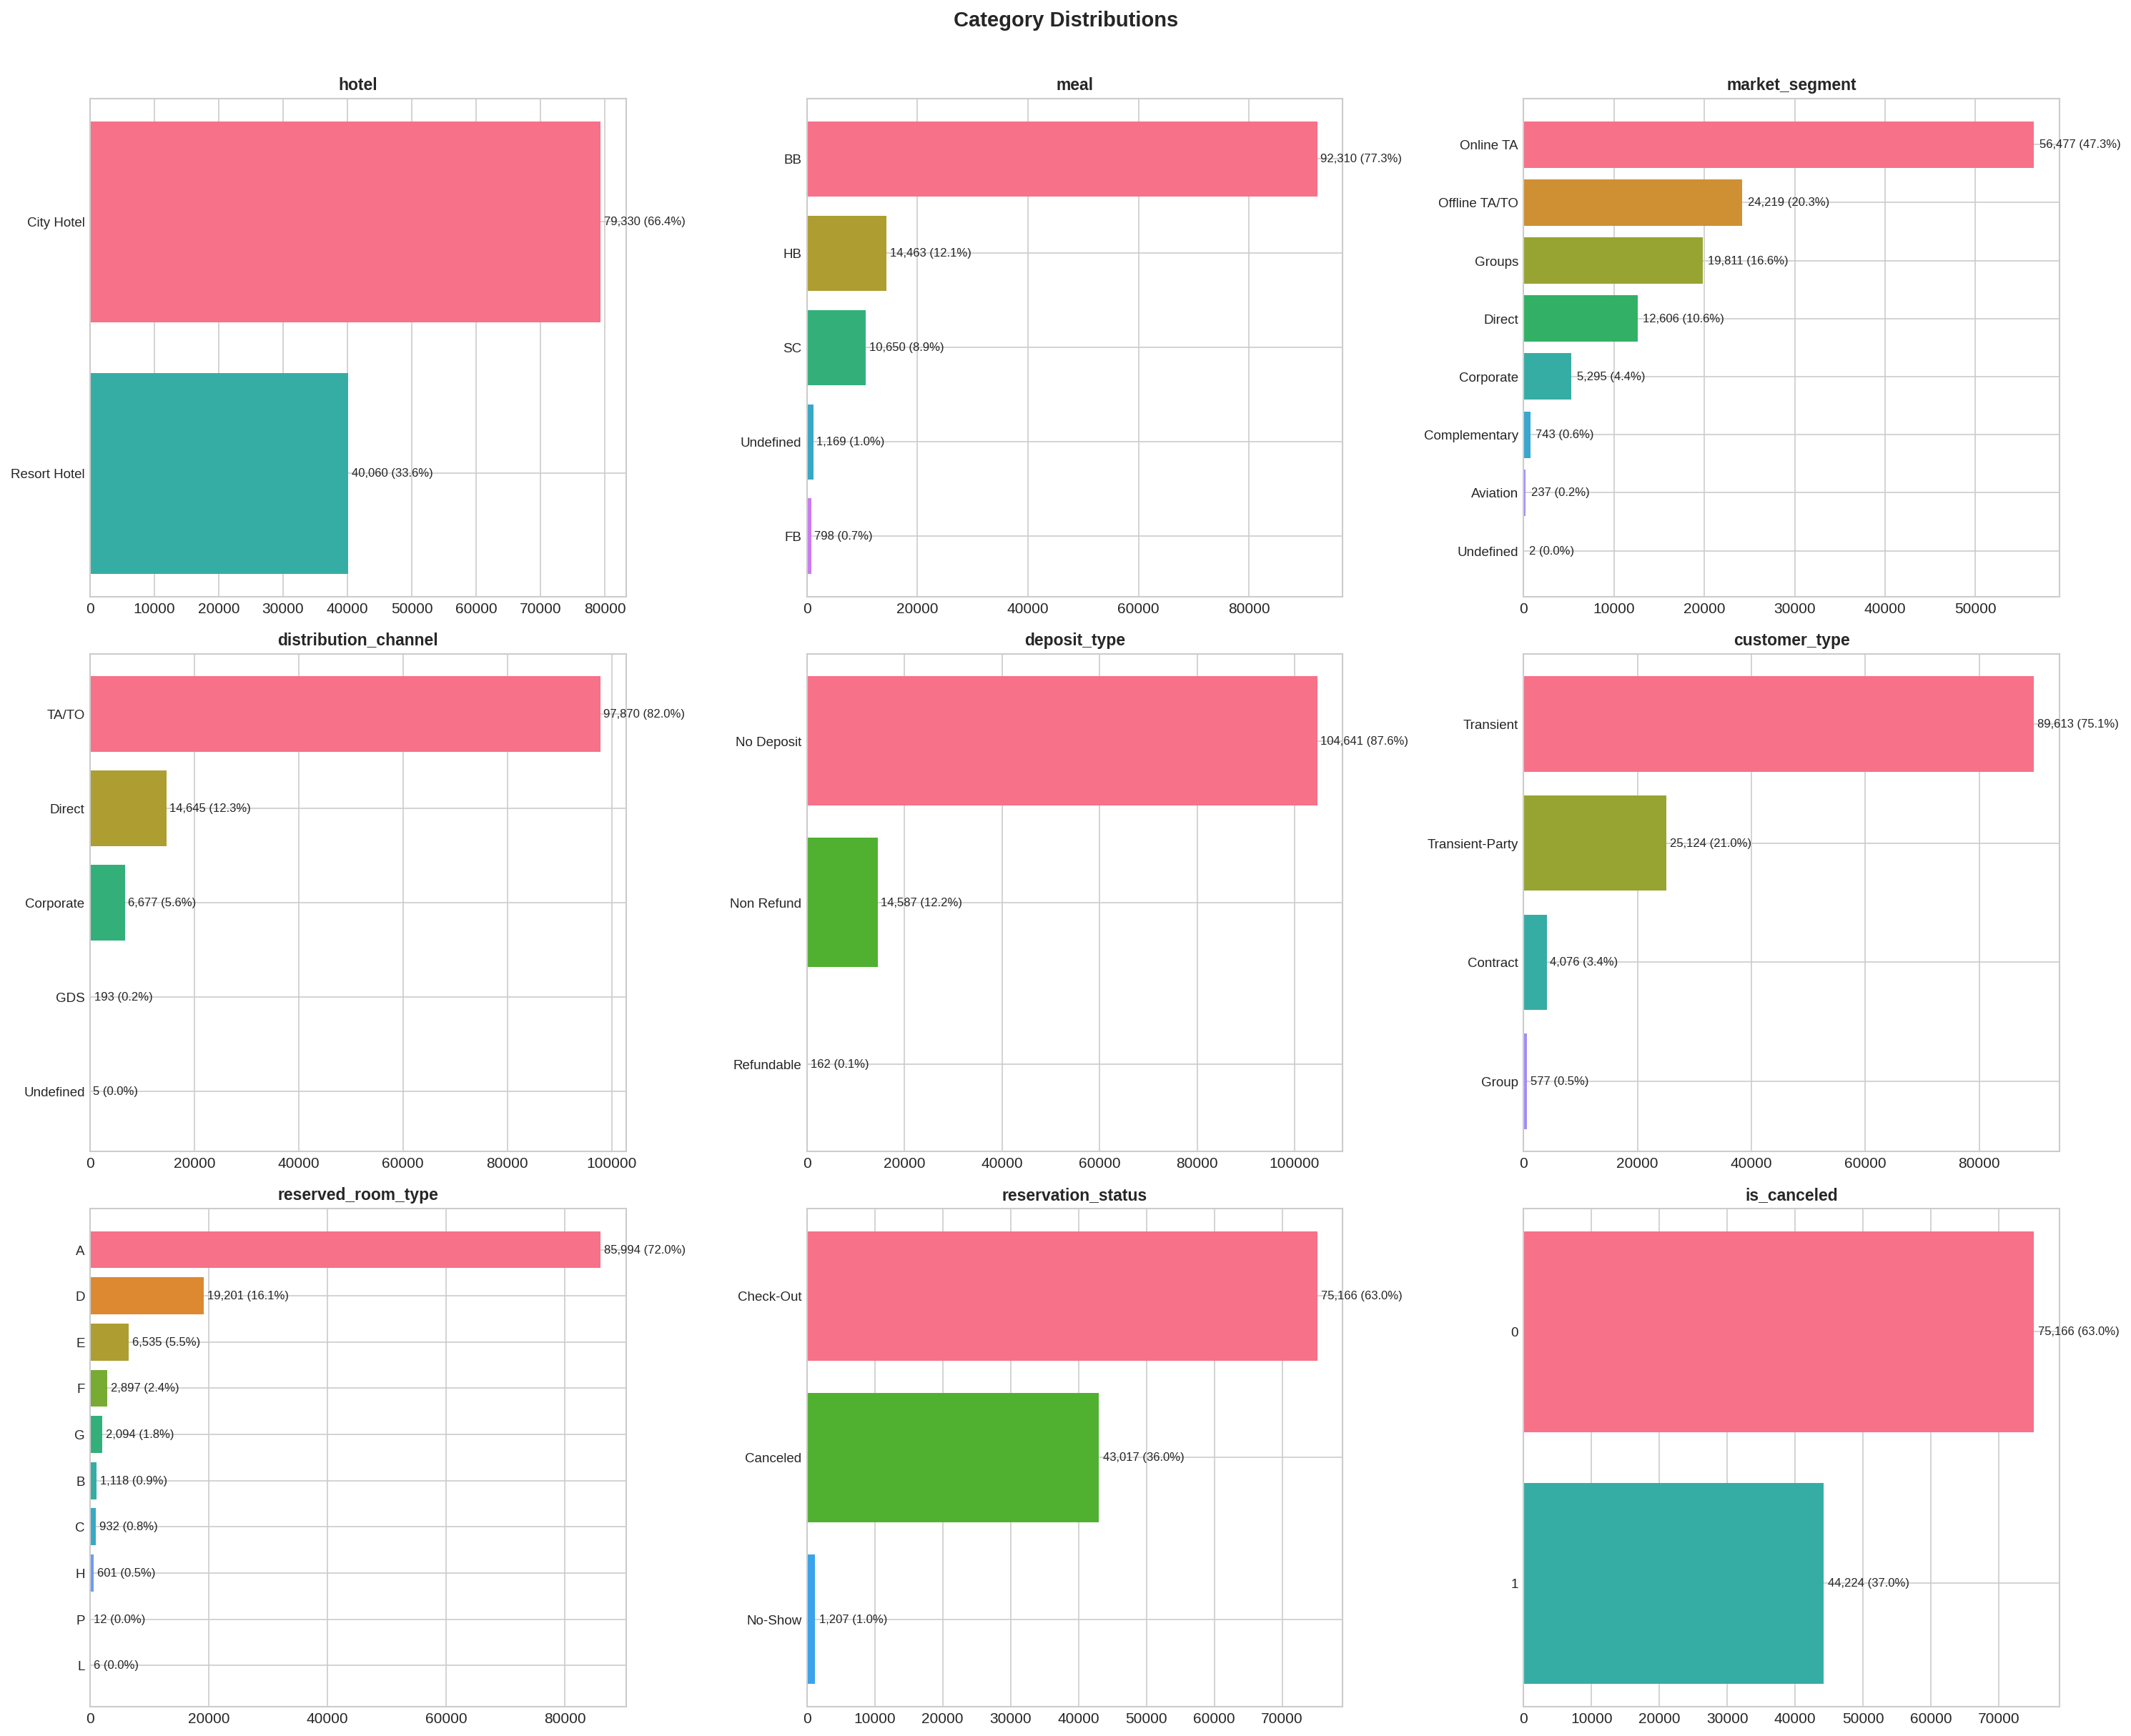

In [ ]:
# Top Category Value Counts
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
axes = axes.flatten()
plot_cats = ['hotel', 'meal', 'market_segment', 'distribution_channel', 'deposit_type',
             'customer_type', 'reserved_room_type', 'reservation_status', 'is_canceled']

for i, col in enumerate(plot_cats):
    ax = axes[i]
    vc = df[col].value_counts().head(10)
    bars = ax.barh(range(len(vc)), vc.values, color=sns.color_palette("husl", len(vc)))
    ax.set_yticks(range(len(vc)))
    ax.set_yticklabels(vc.index, fontsize=9)
    ax.set_title(col, fontsize=11, fontweight='bold')
    for j, v in enumerate(vc.values):
        ax.text(v + len(df)*0.005, j, f'{v:,} ({v/len(df)*100:.1f}%)', va='center', fontsize=8)
    ax.invert_yaxis()
plt.suptitle('Categorical Variable Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# Rare Category Analysis (< 3% threshold)
print("RARE CATEGORIES (appearing in < 3% of records)\n")
cat_cols = ['hotel','meal','market_segment','distribution_channel',
            'deposit_type','customer_type','reserved_room_type']

for col in cat_cols:
    vc = df[col].value_counts(normalize=True) * 100
    rare = vc[vc < 3]
    if len(rare) > 0:
        print(f"  {col}:")
        for val, pct in rare.items():
            action = "→ GROUP into 'Other'" if pct < 1 else "→ KEEP (borderline)"
            print(f"    {val:25s}: {pct:5.2f}%  {action}")
        print()

print("Recommendation: Group categories with < 1% into 'Other' for modeling stability.")
print("Keep borderline categories (1-3%) as they may carry predictive signal.")


RARE CATEGORIES (appearing in < 3% of records)

  meal:
    Undefined                :  0.98%  → GROUP into 'Other'
    FB                       :  0.67%  → GROUP into 'Other'

  market_segment:
    Complementary            :  0.62%  → GROUP into 'Other'
    Aviation                 :  0.20%  → GROUP into 'Other'
    Undefined                :  0.00%  → GROUP into 'Other'

  distribution_channel:
    GDS                      :  0.16%  → GROUP into 'Other'
    Undefined                :  0.00%  → GROUP into 'Other'

  deposit_type:
    Refundable               :  0.14%  → GROUP into 'Other'

  customer_type:
    Group                    :  0.48%  → GROUP into 'Other'

  reserved_room_type:
    B                        :  0.94%  → GROUP into 'Other'
    C                        :  0.78%  → GROUP into 'Other'
    H                        :  0.50%  → GROUP into 'Other'
    P                        :  0.01%  → GROUP into 'Other'
    L                        :  0.01%  → GROUP into 'Other'

R

---## Phase D: Bivariate & Multivariate RelationshipsExamining how features relate to each other and to the target variable (`is_canceled`) through correlations, group comparisons, and cross-tabulations.

In [ ]:
# Correlation Matrix & Top Pairs
corr_cols = ['is_canceled','lead_time','stays_in_weekend_nights','stays_in_week_nights',
             'adults','children','babies','previous_cancellations',
             'previous_bookings_not_canceled','booking_changes','days_in_waiting_list',
             'adr','required_car_parking_spaces','total_of_special_requests']
corr_matrix = df[corr_cols].corr()

# Extract top pairs
pairs = []
for i in range(len(corr_cols)):
    for j in range(i+1, len(corr_cols)):
        pairs.append((corr_cols[i], corr_cols[j], corr_matrix.iloc[i,j]))
pairs.sort(key=lambda x: abs(x[2]), reverse=True)

print("TOP 5 STRONGEST CORRELATIONS\n")
for rank, (c1, c2, r) in enumerate(pairs[:5], 1):
    direction = "↑↑" if r > 0 else "↑↓"
    print(f"  {rank}. {c1:35s} ↔ {c2:35s}: r = {r:+.4f} {direction}")

print("\nTOP 5 CORRELATIONS WITH TARGET (is_canceled):")
target_corrs = corr_matrix['is_canceled'].drop('is_canceled').abs().sort_values(ascending=False)
for col, r in target_corrs.head(5).items():
    sign = corr_matrix.loc['is_canceled', col]
    direction = "POSITIVE" if sign > 0 else "NEGATIVE"
    print(f"  {col:40s}: |r| = {r:.4f} ({direction})")


TOP 5 STRONGEST CORRELATIONS

  1. stays_in_weekend_nights            ↔ stays_in_week_nights              : r = +0.4987 ↑↑
  2. is_canceled                        ↔ lead_time                         : r = +0.2931 ↑↑
  3. is_canceled                        ↔ total_of_special_requests         : r = -0.2347 ↑↓
  4. is_canceled                        ↔ required_car_parking_spaces       : r = -0.1955 ↑↓
  5. adults                             ↔ adr                               : r = +0.1802 ↑↑

TOP 5 CORRELATIONS WITH TARGET (is_canceled):
  lead_time                               : |r| = 0.2931 (POSITIVE)
  total_of_special_requests               : |r| = 0.2347 (NEGATIVE)
  required_car_parking_spaces             : |r| = 0.1955 (NEGATIVE)
  booking_changes                         : |r| = 0.1444 (NEGATIVE)
  previous_cancellations                  : |r| = 0.1101 (POSITIVE)


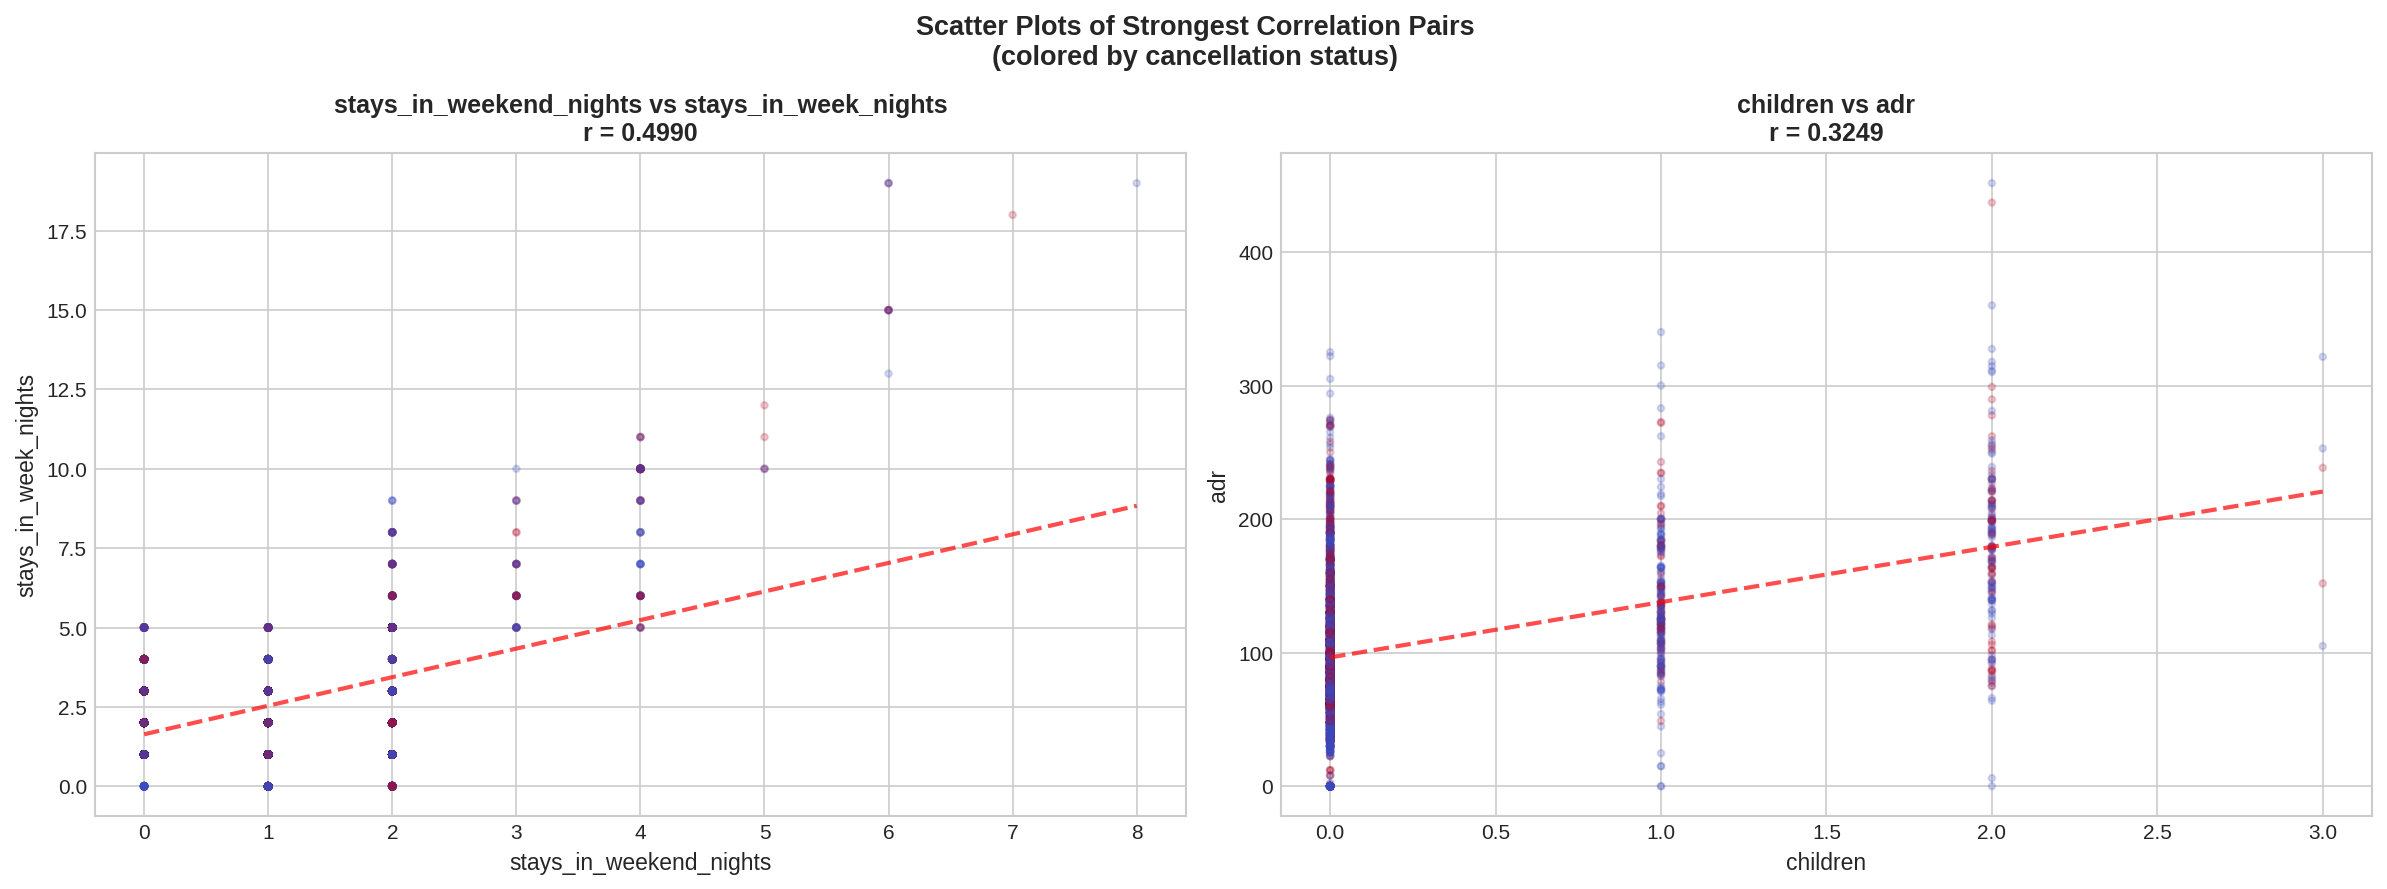


Interpretation:
  1. Weekend & weekday nights are moderately correlated (r=0.50) — longer stays
     include both weekday and weekend portions, as expected.
  2. Lead time strongly separates canceled vs non-canceled bookings — canceled
     bookings are booked much further in advance (median 113 vs 45 days).


In [ ]:
# Scatter Plots of Strongest Correlations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: stays_in_weekend vs stays_in_week
sample = df.sample(5000, random_state=42)
ax = axes[0]
scatter = ax.scatter(sample['stays_in_weekend_nights'], sample['stays_in_week_nights'],
                     alpha=0.2, s=10, c=sample['is_canceled'], cmap='coolwarm')
ax.set_xlabel('stays_in_weekend_nights')
ax.set_ylabel('stays_in_week_nights')
ax.set_title('Weekend vs Weekday Nights (r=+0.50)\nColored by Cancellation', fontweight='bold')

# Plot 2: lead_time vs is_canceled (violin)
ax = axes[1]
parts = ax.violinplot([df[df['is_canceled']==0]['lead_time'],
                       df[df['is_canceled']==1]['lead_time']],
                      positions=[0,1], showmeans=True, showmedians=True)
ax.set_xticks([0,1])
ax.set_xticklabels(['Not Canceled', 'Canceled'])
ax.set_ylabel('Lead Time (days)')
ax.set_title('Lead Time Distribution by Cancellation Status\n(r=+0.29)', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  1. Weekend & weekday nights are moderately correlated (r=0.50) — longer stays")
print("     include both weekday and weekend portions, as expected.")
print("  2. Lead time strongly separates canceled vs non-canceled bookings — canceled")
print("     bookings are booked much further in advance (median 113 vs 45 days).")


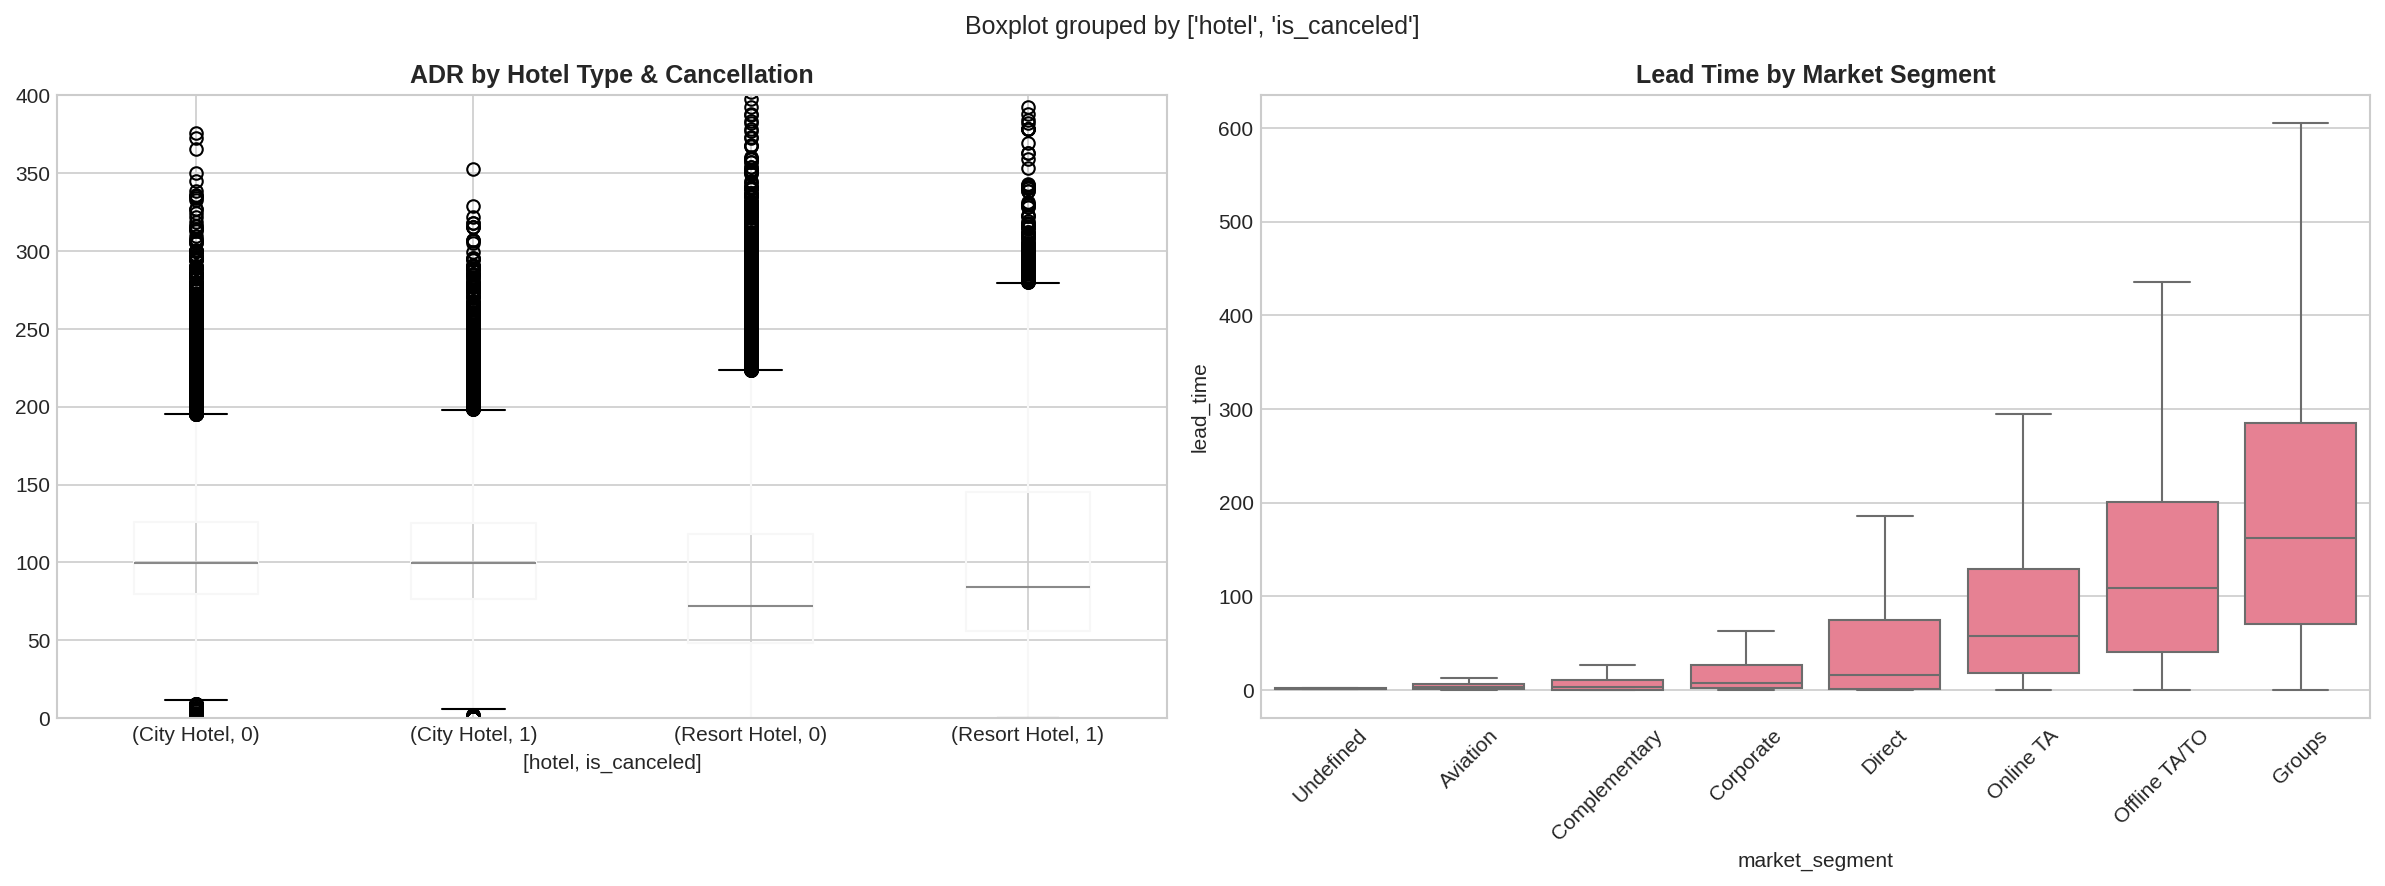

In [ ]:
# Numeric Variable Grouped by Category
print("ADR BY HOTEL TYPE\n")
adr_by_hotel = df.groupby('hotel')['adr'].agg(['mean','median','std','count']).round(2)
display(adr_by_hotel)

print("\nLEAD TIME BY MARKET SEGMENT\n")
lt_by_seg = df.groupby('market_segment')['lead_time'].agg(['mean','median','std','count']).round(2)
display(lt_by_seg.sort_values('median', ascending=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=df, x='hotel', y='adr', hue='is_canceled', ax=axes[0], showfliers=False)
axes[0].set_title('ADR by Hotel Type & Cancellation Status', fontweight='bold')
axes[0].set_ylim(0, 300)

segment_order = df.groupby('market_segment')['lead_time'].median().sort_values().index
sns.boxplot(data=df, x='market_segment', y='lead_time', order=segment_order, ax=axes[1], showfliers=False)
axes[1].set_title('Lead Time by Market Segment', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


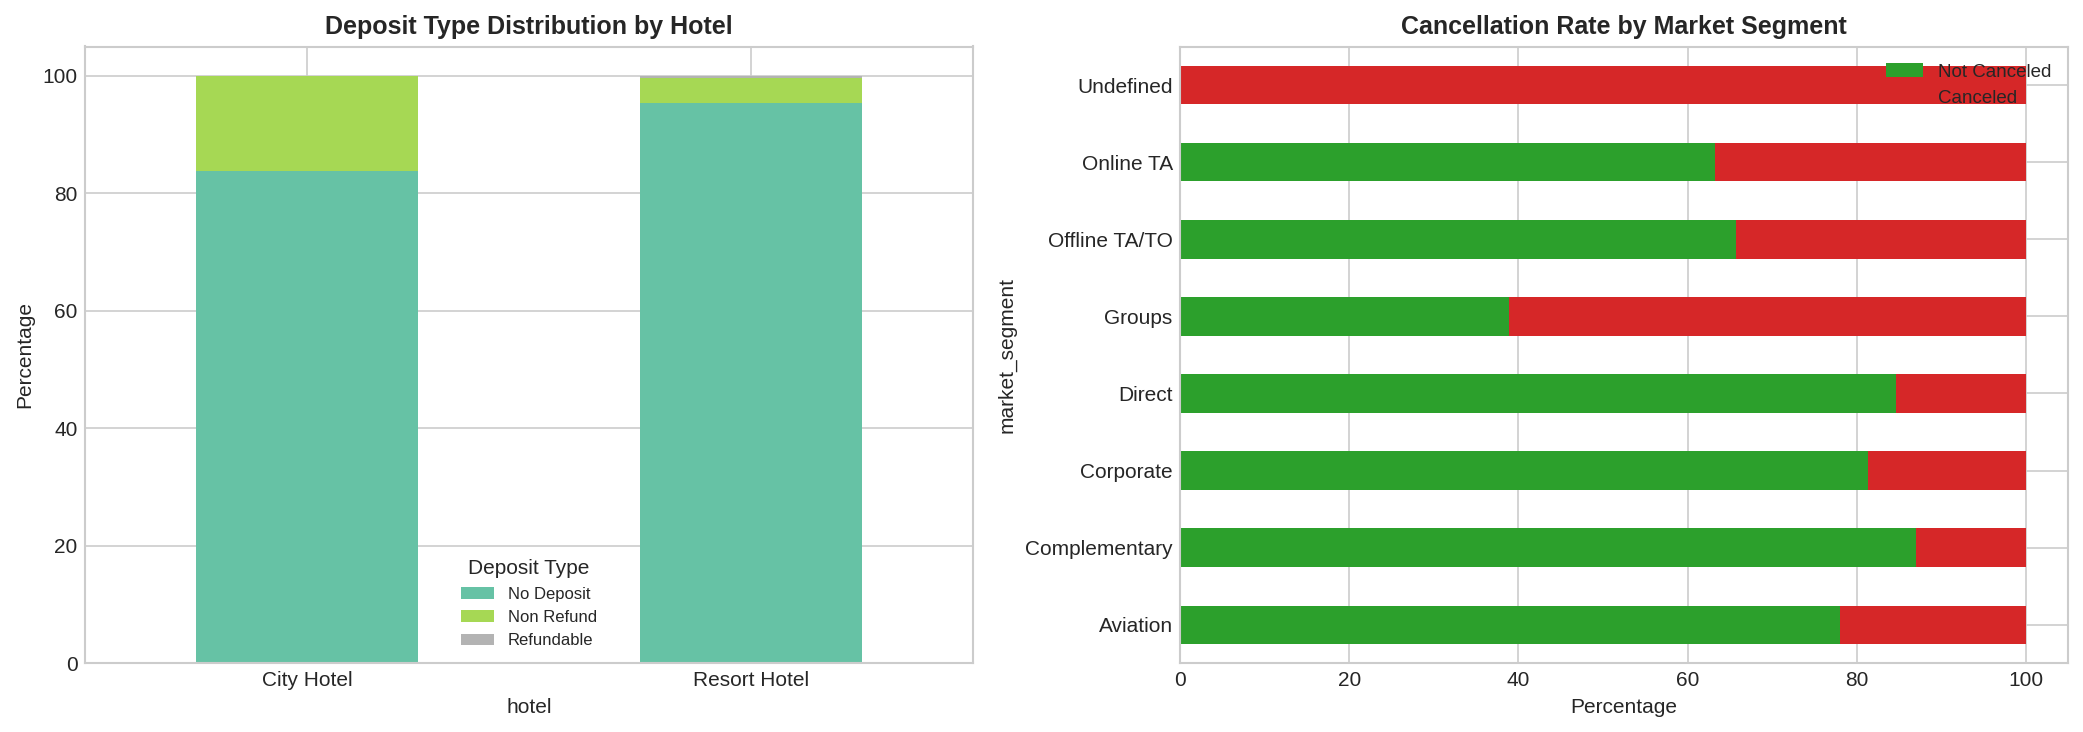


Key Finding: City Hotels have higher cancellation rate (41.7% vs 27.8%)
Groups segment has the highest cancellation rate at 61.1%


In [ ]:
# Cross-Tabulation Analysis
print("CROSSTAB: Hotel Type × Deposit Type (row %)\n")
ct1 = pd.crosstab(df['hotel'], df['deposit_type'], normalize='index').round(4) * 100
display(ct1)

print("\nCROSSTAB: Hotel Type × Cancellation\n")
ct2 = pd.crosstab(df['hotel'], df['is_canceled'], margins=True)
ct2_pct = pd.crosstab(df['hotel'], df['is_canceled'], normalize='index').round(4) * 100
print("Counts:")
display(ct2)
print("\nRow Percentages:")
display(ct2_pct)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ct_plot = pd.crosstab(df['hotel'], df['deposit_type'], normalize='index') * 100
ct_plot.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2')
axes[0].set_title('Deposit Type by Hotel', fontweight='bold')
axes[0].set_ylabel('Percentage')
axes[0].tick_params(axis='x', rotation=0)

ct_cancel = pd.crosstab(df['market_segment'], df['is_canceled'], normalize='index') * 100
ct_cancel.plot(kind='barh', stacked=True, ax=axes[1], color=['#2ca02c', '#d62728'])
axes[1].set_title('Cancellation Rate by Market Segment', fontweight='bold')
axes[1].set_xlabel('Percentage')
axes[1].legend(['Not Canceled', 'Canceled'])
plt.tight_layout()
plt.show()

print("\nKey Finding: City Hotels have higher cancellation rate (41.7% vs 27.8%)")
print("Groups segment has the highest cancellation rate at 61.1%")


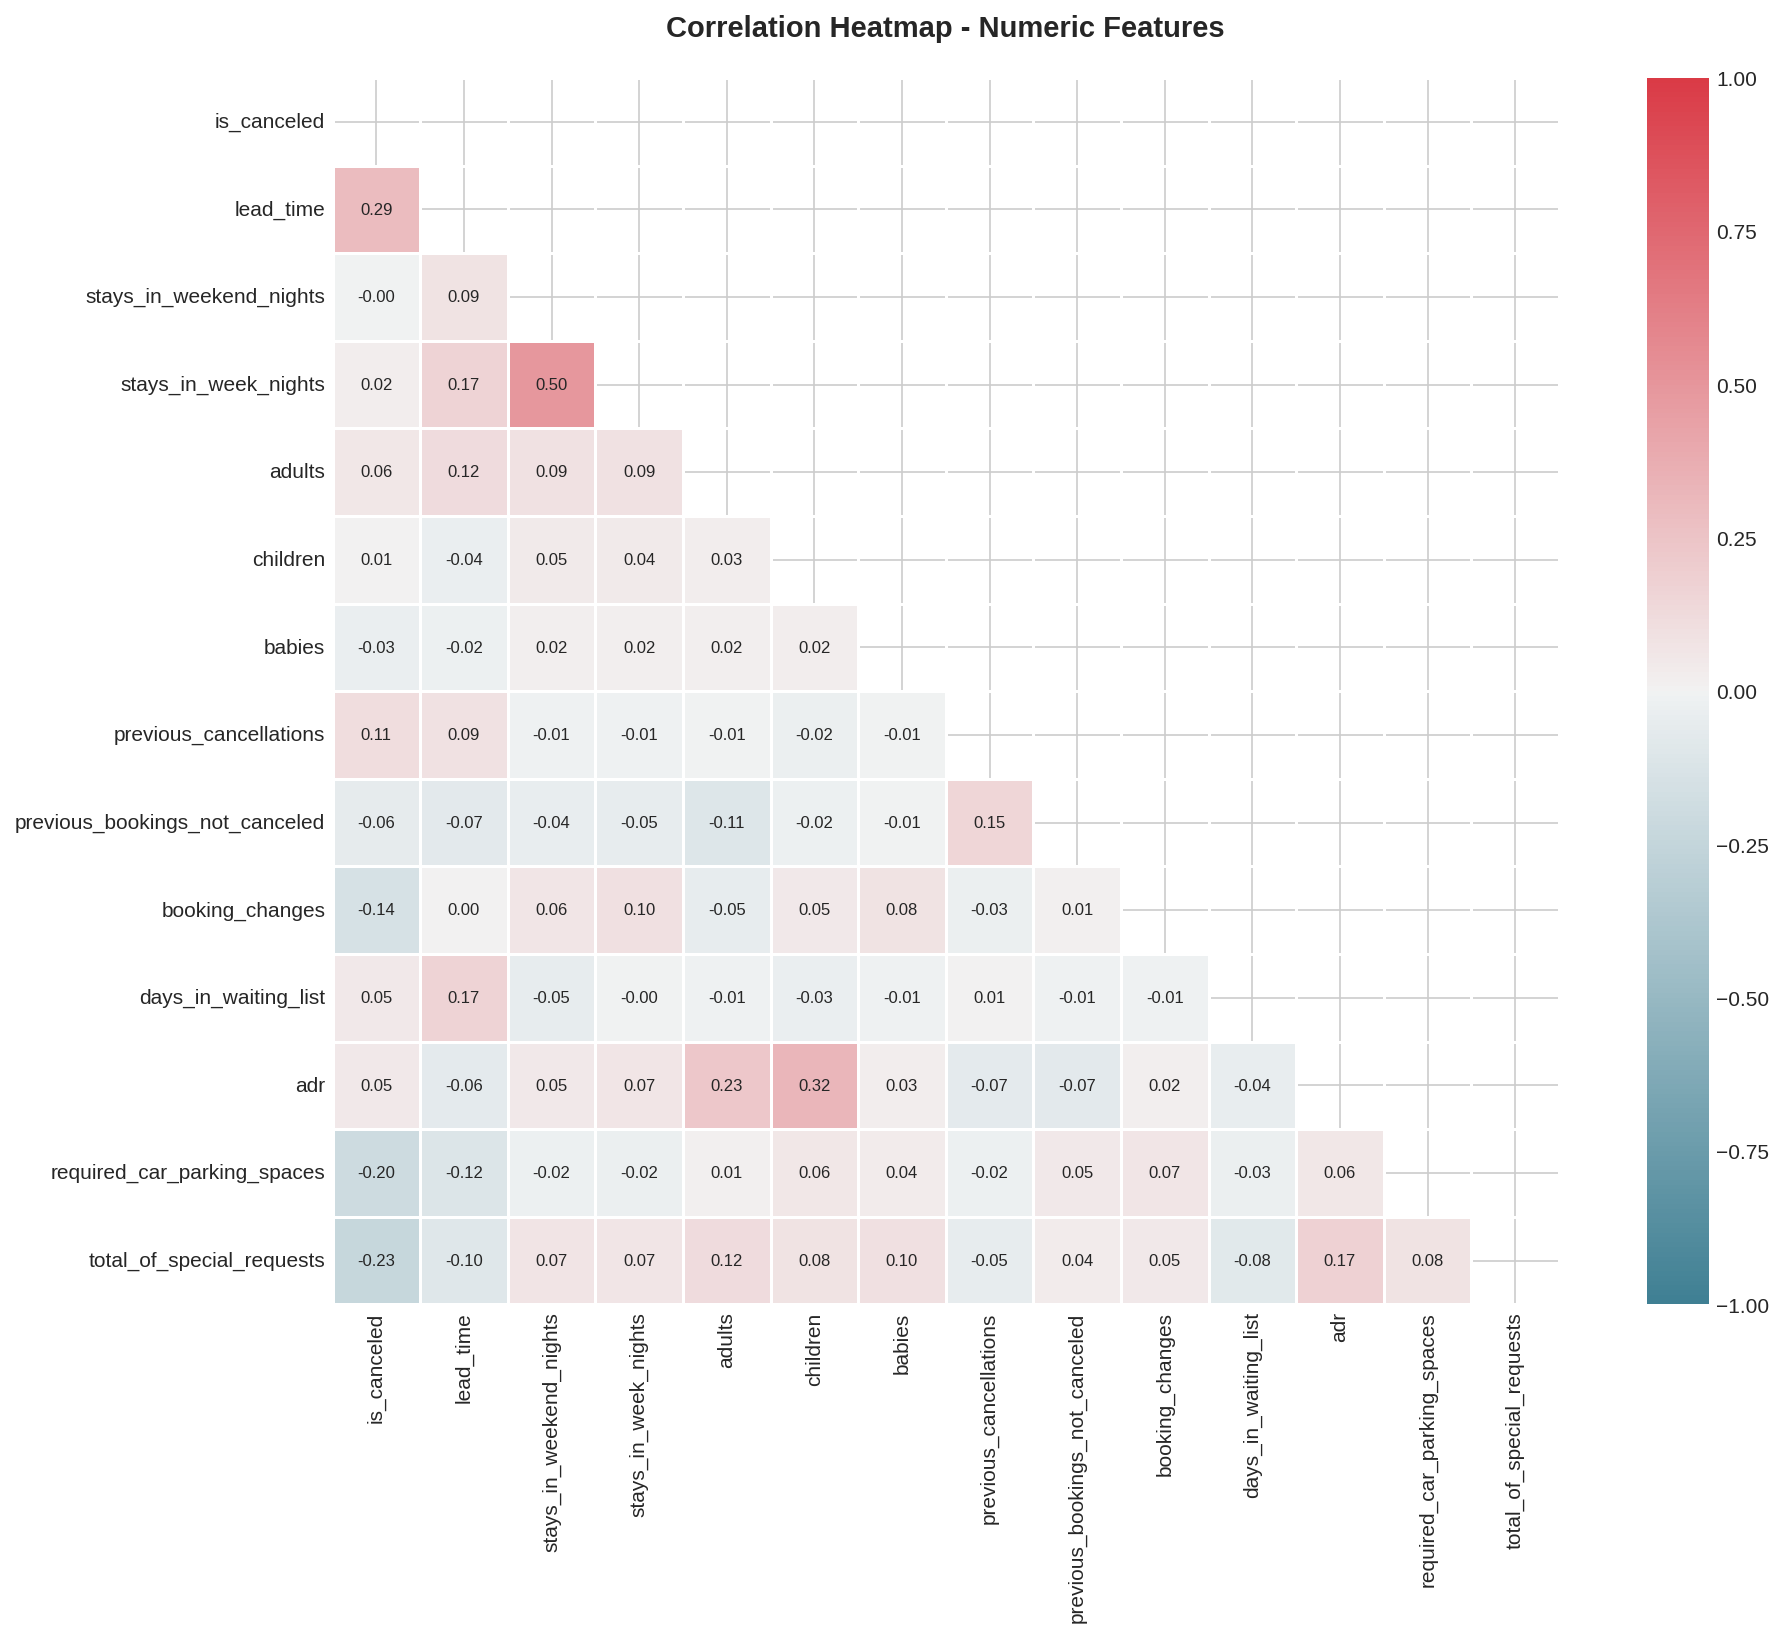


CORRELATION CLUSTERS IDENTIFIED:
  Cluster 1 (Stay Duration): weekend_nights ↔ week_nights (r=+0.50)
  Cluster 2 (Cancellation): is_canceled ↔ lead_time (+), special_requests (-)
  Cluster 3 (Guest History): previous_cancellations, previous_bookings_not_canceled
  Cluster 4 (Pricing): adr ↔ adults (+0.18), weakly linked to stay duration

Notable: Most correlations are weak (<0.3), suggesting non-linear relationships
that tree-based models will capture better than linear models.


In [ ]:
# Correlation Heatmap
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr_matrix, mask=mask, cmap=cmap, center=0, annot=True, fmt='.2f',
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1, annot_kws={'size': 8})
ax.set_title('Correlation Heatmap — Numeric Features', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nCORRELATION CLUSTERS IDENTIFIED:")
print("  Cluster 1 (Stay Duration): weekend_nights ↔ week_nights (r=+0.50)")
print("  Cluster 2 (Cancellation): is_canceled ↔ lead_time (+), special_requests (-)")
print("  Cluster 3 (Guest History): previous_cancellations, previous_bookings_not_canceled")
print("  Cluster 4 (Pricing): adr ↔ adults (+0.18), weakly linked to stay duration")
print("\nNotable: Most correlations are weak (<0.3), suggesting non-linear relationships")
print("that tree-based models will capture better than linear models.")


---## Phase E: Final EDA Synthesis### Top 5 Key Insights1. **High Cancellation Rate (37%)**: Over one-third of all bookings are canceled. City Hotels suffer disproportionately (41.7% vs 27.8% for Resort Hotels), indicating fundamentally different booking dynamics between hotel types.2. **Lead Time is the Strongest Predictor**: Canceled bookings have a median lead time of 113 days versus just 45 days for honored bookings (r=+0.29). Early bookings serve as "options" that guests exercise by canceling when plans change.3. **Non-Refundable Deposit Paradox**: 99.4% of non-refundable deposit bookings are canceled — counterintuitive until you realize these are likely pricing/revenue management artifacts where the rate is so low that the penalty is acceptable.4. **Repeat Guests Are Loyal**: Only 14.5% of repeat guests cancel versus 37.8% of new guests. Loyalty programs and personalized service have measurable impact on commitment.5. **Market Segment Risk Stratification**: Groups carry 61.1% cancellation risk (block bookings often speculatively held), while Direct (15.3%) and Complementary (13.1%) segments are most reliable.---### Top 5 Data Quality Risks1. **Company Column (94.3% missing)** — Must be dropped; no recovery possible.2. **Zero-Guest Bookings (180 records)** — Logically impossible; remove before modeling.3. **ADR Outliers** — One negative value (-6.38) and one extreme (5,400); cap/remove.4. **Target Leakage** — `reservation_status` and `reservation_status_date` directly encode the target and must be excluded from predictive features.5. **PII Columns** — `name`, `email`, `phone-number`, `credit_card` must be dropped to protect privacy and avoid noise in models.---### Recommended Next Steps**Feature Engineering** (see companion notebook):- `total_stay` = weekend + weekday nights- `total_guests` = adults + children + babies  - `is_family` = 1 if children or babies present- `total_revenue` = ADR × total_stay- `lead_time_bin` = short/medium/long categories- `room_changed` = 1 if reserved ≠ assigned room type**Modeling Approach**:- Baseline: Logistic Regression- Advanced: Random Forest, XGBoost, LightGBM- Evaluation: Precision, Recall, F1, ROC-AUC with stratified CV- Address moderate class imbalance (37/63 split)